## Region of Interest Detection
In computer vision and deep learning, we often do not need to process the entire image.

For example, if we are looking for pedestrians on a sidewalk, why scan the sky?

This is where the Region of Interest (ROI) comes in. Once we highlight the RoI we usually would have to crop the selected region and extract the cropped portion of the image.

Example, let's say, in the car image, we are only interested in the front tyre of the car, or in the fruit image we want to get the top portion of the yellow pear. So, how exactly we do that?

We will learn to do this in this notebook.

What we are going to cover?
- **Defining ROI**: How to crop and focus on specific image areas.

- **Thresholding**: The simplest way to separate objects from backgrounds.

- **Contours**: Finding the mathematical curves that join points along a boundary.

- **Watershed Algorithm**: A "flood-fill" approach to separate overlapping objects.

### Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# from google.colab.patches import cv2_imshow # Specific for Colab

In [2]:
image_path = 'data/car.png'
image = cv2.imread(image_path)

Let us get the utility function to display images from previous notebooks.

In [3]:
# Utility function to display images
def show_image(img, fig_size = None):
      print(img.shape)
      img = img.astype('uint8')

      if fig_size is not None:
          plt.figure(figsize=fig_size)

      plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

(137, 368, 3)


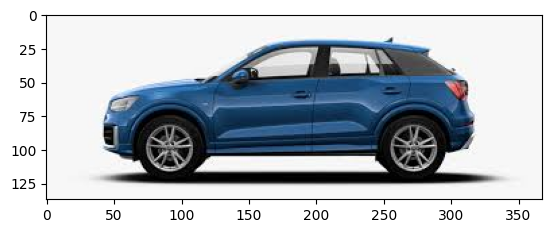

In [4]:
show_image(image)

### Region of Interest

(137, 368, 3)


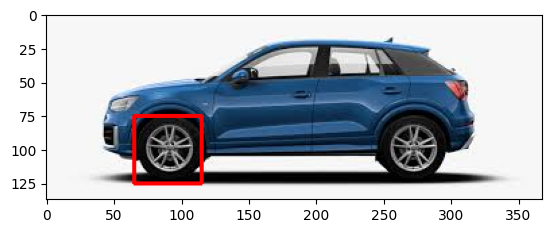

In [5]:
# Utility function to highlight region of interests
def draw_bounding_box(img, x,y,w,h):
    dupicate = img.copy()
    cv2.line(dupicate, (x,y), (x+w,y), color = (0,0,255), thickness = 2)
    cv2.line(dupicate, (x,y), (x,y+h), color = (0,0,255), thickness = 2)
    cv2.line(dupicate, (x,y+h), (x+w,y+h), color = (0,0,255), thickness = 2)
    cv2.line(dupicate, (x+w,y), (x+w,y+h), color = (0,0,255), thickness = 2)

    return dupicate

show_image(draw_bounding_box(image, x = 65, y =75, w = 50, h = 50))

(50, 50, 3)


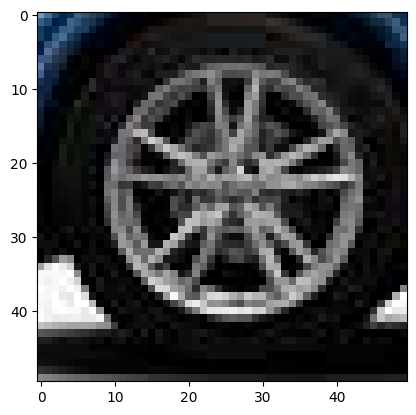

In [6]:
# Pixel position of the top-left coordinate of the bounding box is represented by x and y
# Height and weight of the bounding box is represented by w and h

x = 65; y =75; w = 50; h = 50;
cropped_img = image[y:y+h, x:x+w]
show_image(cropped_img)

An ROI is simply a sub-section of your image. In Python, images are just 2D/3D arrays, so we use array slicing to "crop" them.

ROI significantly reduces computational cost. Processing only a small portion of an image is much faster!

### Image Processing Application: Segmentation Techniques

Image segmentation consists of partitioning an image according to a certain criterion. The image is divided into regions that are both mutually disjoint and collectively cover the entire image - two pixels in the same region satisfy the criterion, but two pixels in two adjacent regions do not. 

The result of segmentation is not unique: it depends on the criterion, the segmentation method, the initialisation of the method, etc. There are many different segmentation methods and this chapter focuses on the more usual ones. Finally, we talk about how to measure the quality of segmentation.

#### Thresholding
To find boundaries, we first turn the image into Binary (Black and White)

(137, 368)


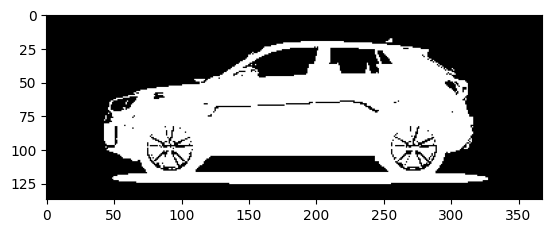

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Pixels above 127 become 255 (white), others become 0 (black)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
show_image(thresh)

#### Contours
Contours are the "outline" of the white shapes in our thresholded image while finding boundaries.

(137, 368, 3)


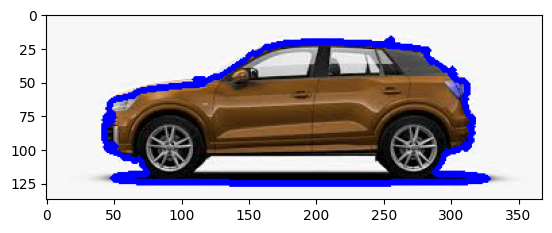

In [10]:
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw the outlines on the original image
show_image(cv2.drawContours(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), contours, -1, (255, 0, 0), 3))

#### The Watershed Algorithm

Classic thresholding fails when two objects (like the car and its associated shadow in the image) are touching. The Watershed Algorithm treats the image like a topographic map and "floods" it with water to find the ridges where objects meet.

In [11]:
# Noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Finding sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Finding sure foreground (using Distance Transform)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Marker labeling
sure_fg = np.uint8(sure_fg)
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1 # Add one to all labels so that background is not 0
markers[cv2.subtract(sure_bg, sure_fg) == 255] = 0 # Unknown regions

# Apply Watershed
markers = cv2.watershed(image, markers)
image[markers == -1] = [0, 0, 255] # Mark boundaries in Red

(137, 368, 3)


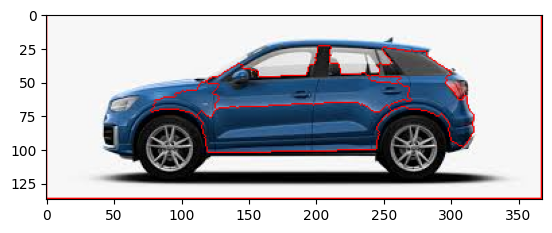

In [12]:
show_image(image)

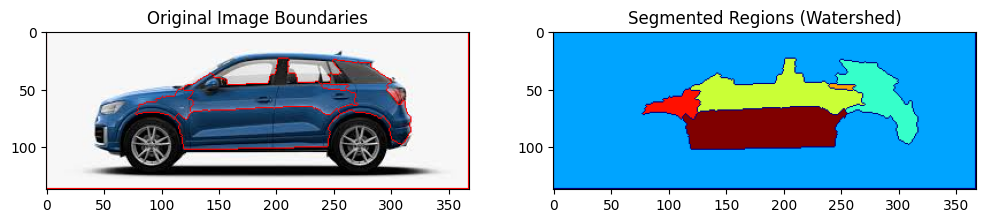

In [13]:
# Convert markers to a 8-bit image so we can apply a colormap
# The markers array has values from -1 (boundaries) to N (object ID)
# We normalize it to 0-255 for visualization
marker_img = np.uint8(cv2.normalize(markers, None, 0, 255, cv2.NORM_MINMAX))

# Apply a Jet colormap (it makes each segment look like a different color)
colored_markers = cv2.applyColorMap(marker_img, cv2.COLORMAP_JET)

# Display the original image and the segmented version side-by-side
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image Boundaries")
# Show the boundaries we drew earlier (markers == -1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Segmented Regions (Watershed)")
plt.imshow(cv2.cvtColor(colored_markers, cv2.COLOR_BGR2RGB))

plt.show()

Each color represents a different "catchment basin." The algorithm treats the image like a landscape where high pixel intensity represents hills and low intensity represents valleys. Even if two regions within the image was overlapping, the Watershed algorithm tries to find the "dam" (the ridge) between them

We learned about the importance of region of interest (RoIs) in images and have applied many techniques such as thresholding, contours and watershed algorithm for RoI detection and extraction.